# Native FINAL vs input spectra (`7.5_spectra`)

Compare **SEDs from disk** on each file’s native wavelength grid (no lookup-table / common-wavelength interpolation) to **original / smoothed / mangled** input spectra.

- **SED products:** `spliced`, `full_gp`, or **both** (two curves).
- **Phase vs MJD:** set `t0_mjd` (explosion/merger MJD) and either `phase_query_days` (days since `t0`) **or** `mjd_query` (observer MJD). If `phase_query_days` is not `None`, it **wins** over `mjd_query`.
- **`time_window`:** days; input spectra within ±`time_window` of the effective query MJD are plotted (else nearest).
- **Redshift:** with `z > 0`, **only input** spectra are rest-framed (λ/(1+z), F×(1+z)); FINAL curves stay as stored (matches `7.5_comparison_check_log`).
- **Median-normalized mode:** each plotted curve is divided by the finite `nanmedian` of its flux; non-positive or empty medians skip with a warning.
- **Batch:** saves one PNG per **distinct** observer `spec_mjd` (sorted union from the indexed FINAL trees; several files can share one MJD).


In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt

import pipeline_config as pconf
from comparison_check_log_utils import (
    resolve_final_directory,
    twodim_final_branch,
    nearest_final_spectrum_native,
    index_final_native_files,
    collect_input_spectra_for_mode,
    resolve_comparison_spectrum_path,
    load_comparison_spectrum_xy,
)


In [2]:
# ---------------------------------------------------------------------------
# Global paths & knobs (edit here)
# ---------------------------------------------------------------------------
COCO_PATH = pconf.COCO_PATH
SNNAME = pconf.SNNAME_DEFAULT
DATALC_PATH = os.path.join(COCO_PATH, "Inputs", "Photometry", "4_LCs_late_extrapolated")
FINAL_FLUX_ON_DISK = "auto"
FINAL_VARIANT = "as_observed"
FINAL_SUFFIXES_TO_LOAD = None  # or e.g. ("_FINAL_spec_FL.txt",)
TWODIM_MODE_SHORT = pconf.MODE_EXTRAPOLATE_SHORT  # "extrapolate" | "extend"

z_redshift = 0.00984
t0_mjd = float(pconf.SN_EXPLOSION_MJD.get(SNNAME, 57982.52851852))


### Resolved FINAL directories (spliced / full_gp)

In [3]:
def _final_dir(product: str) -> str:
    branch = twodim_final_branch(TWODIM_MODE_SHORT, product)
    return resolve_final_directory(
        COCO_PATH, SNNAME, FINAL_VARIANT, twodim_branch=branch
    )

dir_spliced = _final_dir(pconf.SUBDIR_SPLICED)
dir_full_gp = _final_dir(pconf.SUBDIR_FULL_GP)
print("spliced:", dir_spliced)
print("full_gp:", dir_full_gp)


spliced: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/extrapolate/spliced/as_observed
full_gp: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/extrapolate/full_gp/as_observed


### Core plotting

`plot_native_epoch` uses `nearest_final_spectrum_native` per SED directory. Effective query MJD:
`t0_mjd + phase_query_days` if `phase_query_days is not None`, else `mjd_query`, else `spec_mjd_fallback` (batch driver).


In [4]:

def effective_query_mjd(
    *,
    phase_query_days,
    mjd_query,
    t0_mjd,
    spec_mjd_fallback=None,
):
    if phase_query_days is not None:
        return float(t0_mjd) + float(phase_query_days)
    if mjd_query is not None:
        return float(mjd_query)
    if spec_mjd_fallback is not None:
        return float(spec_mjd_fallback)
    raise ValueError(
        "Set phase_query_days, mjd_query, or spec_mjd_fallback (batch) to choose an epoch."
    )


def median_normalize_flux(wl, fl, tag=""):
    wl = np.asarray(wl, dtype=float)
    fl = np.asarray(fl, dtype=float)
    m = np.isfinite(fl)
    if not np.any(m):
        warnings.warn("median norm skip (%s): no finite flux" % tag)
        return wl, fl
    med = float(np.nanmedian(fl[m]))
    if (not np.isfinite(med)) or med <= 0.0:
        warnings.warn("median norm skip (%s): median=%s" % (tag, med))
        return wl, fl
    return wl, fl / med


def plot_native_epoch(
    *,
    phase_query_days=None,
    mjd_query=None,
    t0_mjd=None,
    spec_mjd_fallback=None,
    which_sed="spliced",
    dir_spliced=None,
    dir_full_gp=None,
    mode="smoothed",
    list_file=None,
    original_spec_dir=None,
    time_window=0.0,
    z=0.0,
    sed_scale=1.0,
    input_scale=1.0,
    normalize_median=False,
    ax=None,
    figsize=(9, 5.5),
    show=True,
    title_prefix=None,
):
    """Plot native FINAL (spliced and/or full_gp) vs input spectra.

    which_sed: "spliced" | "full_gp" | "both"
    """
    import matplotlib.pyplot as plt

    if t0_mjd is None:
        t0_mjd = float(pconf.SN_EXPLOSION_MJD.get(SNNAME, np.nan))
    q_mjd = effective_query_mjd(
        phase_query_days=phase_query_days,
        mjd_query=mjd_query,
        t0_mjd=t0_mjd,
        spec_mjd_fallback=spec_mjd_fallback,
    )

    branches = []
    which_sed = str(which_sed).lower()
    if which_sed not in ("spliced", "full_gp", "both"):
        raise ValueError("which_sed must be spliced, full_gp, or both")
    if which_sed in ("spliced", "both"):
        branches.append(("SED spliced", dir_spliced))
    if which_sed in ("full_gp", "both"):
        branches.append(("SED full_gp", dir_full_gp))

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for j, (sed_label, fdir) in enumerate(branches):
        if not fdir:
            warnings.warn("skip %s: no directory" % sed_label)
            continue
        try:
            smjd, sed_wl, sed_fl, sed_fname = nearest_final_spectrum_native(
                fdir,
                q_mjd,
                COCO_PATH,
                SNNAME,
                flux_on_disk=FINAL_FLUX_ON_DISK,
                datalc_path=DATALC_PATH,
                final_suffixes=FINAL_SUFFIXES_TO_LOAD,
            )
        except Exception as e:
            warnings.warn("nearest FINAL failed for %s: %s" % (sed_label, e))
            continue
        sed_fl = sed_scale * np.asarray(sed_fl, dtype=float)
        sed_wl = np.asarray(sed_wl, dtype=float)
        if normalize_median:
            sed_wl, sed_fl = median_normalize_flux(
                sed_wl, sed_fl, tag="%s %s" % (sed_label, sed_fname)
            )
        c = "black" if j == 0 and which_sed != "both" else color_cycle[j % len(color_cycle)]
        ls = "-" if j == 0 else "--"
        if which_sed == "both":
            c = color_cycle[j % len(color_cycle)]
            ls = "-" if j == 0 else "--"
        ax.plot(
            sed_wl,
            sed_fl,
            color=c,
            ls=ls,
            lw=1.6,
            label="%s (t=%.6f MJD)" % (sed_label, smjd),
            alpha=0.9,
        )

    mode = str(mode).lower()
    orig_paths, orig_mjds, _odir, list_ref = collect_input_spectra_for_mode(
        mode, list_file, original_spec_dir, SNNAME, COCO_PATH
    )
    if not orig_paths or orig_mjds.size == 0:
        warnings.warn("No input spectra (mode=%r list_ref=%r)" % (mode, list_ref))
        idxs = np.array([], dtype=int)
    elif time_window and time_window > 0:
        idxs = np.where(np.abs(orig_mjds - q_mjd) <= time_window)[0]
        if idxs.size == 0:
            idxs = np.array([int(np.argmin(np.abs(orig_mjds - q_mjd)))])
    else:
        idxs = np.array([int(np.argmin(np.abs(orig_mjds - q_mjd)))])

    fdisk = FINAL_FLUX_ON_DISK if mode == "mangled" else "auto"
    mode_label = {"smoothed": "Smoothed", "original": "Original", "mangled": "Mangled"}[mode]

    for k, idx in enumerate(idxs):
        orig_path = orig_paths[int(idx)]
        orig_mjd = float(orig_mjds[int(idx)])
        disk_path = resolve_comparison_spectrum_path(
            orig_path, mode, _odir, COCO_PATH, SNNAME
        )
        try:
            orig_wl, orig_flux = load_comparison_spectrum_xy(disk_path, mode, fdisk)
        except Exception as e:
            warnings.warn("Could not load %s: %s" % (disk_path, e))
            continue
        orig_wl = np.asarray(orig_wl, dtype=float)
        orig_flux = input_scale * np.asarray(orig_flux, dtype=float)
        if z > 0.0:
            orig_wl = orig_wl / (1.0 + z)
            orig_flux = orig_flux * (1.0 + z)
        if normalize_median:
            orig_wl, orig_flux = median_normalize_flux(
                orig_wl, orig_flux, tag="input %s" % disk_path
            )
        ax.plot(
            orig_wl,
            orig_flux,
            label="%s (t=%.6f MJD)" % (mode_label, orig_mjd),
            color=color_cycle[(k + len(branches)) % len(color_cycle)],
            alpha=0.75,
            lw=1.2,
        )

    phase_eff = q_mjd - float(t0_mjd)
    ax.set_xlabel("Wavelength (Å)")
    if normalize_median:
        ax.set_ylabel(r"$F_\lambda \,/\, \mathrm{median}(F_\lambda)$")
    else:
        ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    parts = []
    if title_prefix:
        parts.append(str(title_prefix))
    parts.append(
        "%s near MJD %.6f (+%.4f d since t0=%.6f)"
        % (mode_label, q_mjd, phase_eff, float(t0_mjd))
    )
    ax.set_title("  ".join(parts))
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if show:
        plt.show()
    return fig, ax, q_mjd


def union_spec_mjds_for_batch(which_sed, dir_spliced, dir_full_gp):
    """Sorted unique spec_mjd from indexed FINAL trees (lightweight)."""
    which_sed = str(which_sed).lower()
    out = []
    if which_sed in ("spliced", "both"):
        out.extend(
            index_final_native_files(
                dir_spliced,
                COCO_PATH,
                SNNAME,
                datalc_path=DATALC_PATH,
                final_suffixes=FINAL_SUFFIXES_TO_LOAD,
            )
        )
    if which_sed in ("full_gp", "both"):
        out.extend(
            index_final_native_files(
                dir_full_gp,
                COCO_PATH,
                SNNAME,
                datalc_path=DATALC_PATH,
                final_suffixes=FINAL_SUFFIXES_TO_LOAD,
            )
        )
    mjds = sorted({float(t[0]) for t in out})
    return mjds


### Interactive: one epoch

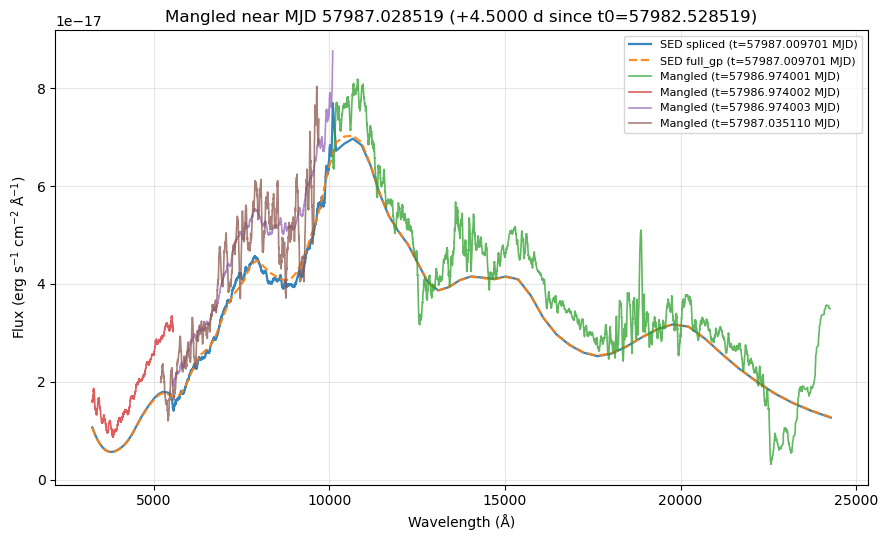

(<Figure size 900x550 with 1 Axes>,
 <Axes: title={'center': 'Mangled near MJD 57987.028519 (+4.5000 d since t0=57982.528519)'}, xlabel='Wavelength (Å)', ylabel='Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)'>,
 57987.02851852)

In [14]:
# Query: phase_query_days wins over mjd_query when not None
phase_query_days = 4.5  # days since t0_mjd; set to None to use mjd_query instead
mjd_query = None  # observer MJD, e.g. t0_mjd + 1.0

which_sed = "both"  # "spliced" | "full_gp" | "both"
mode = "mangled"
time_window = 0.5
normalize_median = False
sed_scale = 1.0
input_scale = 1.0

plot_native_epoch(
    phase_query_days=phase_query_days,
    mjd_query=mjd_query,
    t0_mjd=t0_mjd,
    which_sed=which_sed,
    dir_spliced=dir_spliced,
    dir_full_gp=dir_full_gp,
    mode=mode,
    time_window=time_window,
    z=z_redshift,
    sed_scale=sed_scale,
    input_scale=input_scale,
    normalize_median=normalize_median,
    show=True,
)


### Batch save PNGs (absolute flux)

epochs: 117


KeyboardInterrupt: 

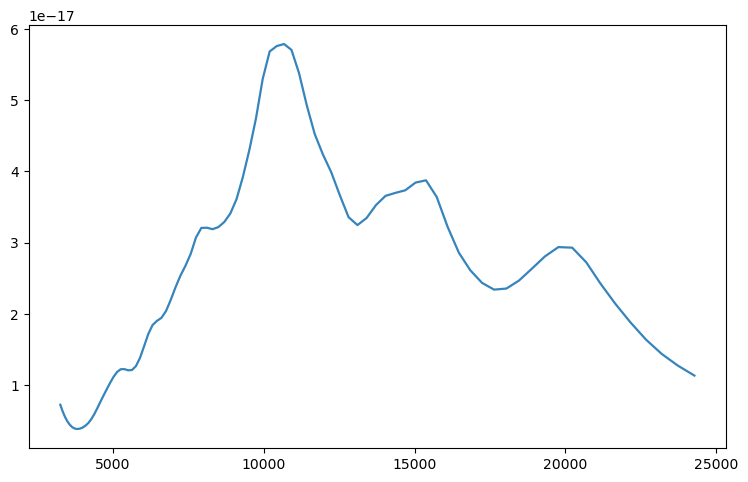

In [6]:
RUN_LABEL = "demo"
SAVE_ROOT = os.path.join(
    COCO_PATH, "Outputs", SNNAME, "spectra_compare_native", RUN_LABEL, "absolute"
)
os.makedirs(SAVE_ROOT, exist_ok=True)

batch_which_sed = "spliced"
batch_mode = "smoothed"
batch_time_window = 0.5
batch_normalize_median = False

mjds = union_spec_mjds_for_batch(batch_which_sed, dir_spliced, dir_full_gp)
print("epochs:", len(mjds))

for spec_mjd in mjds:
    fig, ax, q = plot_native_epoch(
        mjd_query=float(spec_mjd),
        t0_mjd=t0_mjd,
        phase_query_days=None,
        which_sed=batch_which_sed,
        dir_spliced=dir_spliced,
        dir_full_gp=dir_full_gp,
        mode=batch_mode,
        time_window=batch_time_window,
        z=z_redshift,
        normalize_median=batch_normalize_median,
        show=False,
    )
    fn = "native_%s_which=%s_mjd=%.6f.png" % (
        SNNAME, batch_which_sed, float(spec_mjd)
    )
    fig.savefig(os.path.join(SAVE_ROOT, fn), dpi=150, bbox_inches="tight")
    plt.close(fig)
print("wrote under", SAVE_ROOT)


### Batch save PNGs (median-normalized)

In [ ]:
RUN_LABEL = "demo"
SAVE_ROOT_NORM = os.path.join(
    COCO_PATH, "Outputs", SNNAME, "spectra_compare_native", RUN_LABEL, "median_norm"
)
os.makedirs(SAVE_ROOT_NORM, exist_ok=True)

batch_which_sed = "both"
batch_mode = "mangled"
batch_time_window = 0.5
batch_normalize_median = True

mjds = union_spec_mjds_for_batch(batch_which_sed, dir_spliced, dir_full_gp)
for spec_mjd in mjds:
    fig, ax, q = plot_native_epoch(
        mjd_query=float(spec_mjd),
        t0_mjd=t0_mjd,
        which_sed=batch_which_sed,
        dir_spliced=dir_spliced,
        dir_full_gp=dir_full_gp,
        mode=batch_mode,
        time_window=batch_time_window,
        z=z_redshift,
        normalize_median=batch_normalize_median,
        show=False,
    )
    fn = "native_median_%s_which=%s_mjd=%.6f.png" % (
        SNNAME, batch_which_sed, float(spec_mjd)
    )
    fig.savefig(os.path.join(SAVE_ROOT_NORM, fn), dpi=150, bbox_inches="tight")
    plt.close(fig)
print("wrote under", SAVE_ROOT_NORM)


### Phase vs MJD sanity check

For the same `t0_mjd`, `phase_query_days=1.0` should match `mjd_query=t0_mjd+1` up to the nearest-FINAL epoch mapping.


In [ ]:
fig1, ax1, q1 = plot_native_epoch(
    phase_query_days=1.0,
    mjd_query=None,
    t0_mjd=t0_mjd,
    which_sed="spliced",
    dir_spliced=dir_spliced,
    dir_full_gp=dir_full_gp,
    mode="smoothed",
    show=False,
    title_prefix="A: phase=1d",
)
fig2, ax2, q2 = plot_native_epoch(
    phase_query_days=None,
    mjd_query=float(t0_mjd) + 1.0,
    t0_mjd=t0_mjd,
    which_sed="spliced",
    dir_spliced=dir_spliced,
    dir_full_gp=dir_full_gp,
    mode="smoothed",
    show=False,
    title_prefix="B: mjd=t0+1",
)
assert abs(q1 - q2) < 1e-9
plt.close(fig1)
plt.close(fig2)
print("phase vs MJD query consistency OK (q = %.10f)" % q1)
